# Análisis Exploratorio de Datos (EDA) — Give Me Some Credit

**Give Me Some Credit** es un dataset de Kaggle, sacado de una competencia de predicción de riesgo crediticio. La idea es usar información financiera y de comportamiento de los clientes (edad, ingresos mensuales, número de préstamos, uso de líneas de crédito, historial de pagos, atrasos) para estimar qué tan probable es que alguien caiga en dificultades financieras.

La variable objetivo es **SeriousDlqin2yrs**: si el cliente presentó morosidad grave en los siguientes dos años (1) o no (0). Es clasificación binaria, así de simple.

Este EDA sigue el mismo orden de siempre: carga de librerías, estructura de los datos, univariado, bivariado, comparación de medianas con pruebas de hipótesis, y correlación entre variables.

## 1. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats

sns.set_style("white")
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.family"] = "sans-serif"

In [2]:
# Paleta de colores para visualizaciones:
# - estado bueno/malo para el target binario (el color SÍ representa un estado: sin/con morosidad grave)
# - azul de serie única para distribuciones generales (univariado)
# - par divergente azul-rojo con punto medio gris para correlaciones
COLOR_GOOD = "#0ca30c"        # SeriousDlqin2yrs = 0
COLOR_CRITICAL = "#d03b3b"    # SeriousDlqin2yrs = 1
COLOR_SEQ = "#2a78d6"
COLOR_SEQ_DARK = "#184f95"
DIVERGE_LOW, DIVERGE_MID, DIVERGE_HIGH = "#2a78d6", "#f0efec", "#e34948"
GRID_COLOR, AXIS_COLOR, MUTED_TEXT, SECONDARY_TEXT, PRIMARY_TEXT = (
    "#e1e0d9", "#c3c2b7", "#898781", "#52514e", "#0b0b0b"
)
# Función para aplicar estilo consistente a los ejes de los gráficos
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    """Aplica el estilo consistente (spines, grid, tipografía) usado en todo el notebook."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_COLOR)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.tick_params(colors=MUTED_TEXT, labelsize=9)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=11, color=PRIMARY_TEXT, fontweight="bold", loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9, color=SECONDARY_TEXT)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9, color=SECONDARY_TEXT)
    return ax

In [3]:
%pip install xlrd # Instala las dependencias necesarias

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Para graficar uso solo `matplotlib` y `seaborn`, con `pandas`/`numpy` de soporte para el manejo de datos. El mapa de valores faltantes de la sección 2.3, por ejemplo, sale directo de `seaborn.heatmap`.

`scipy.stats` se usa para los diagnósticos descriptivos de forma (asimetría, curtosis) y para Mann-Whitney U en la sección 5. Ya no se usan pruebas formales de normalidad (Kolmogorov-Smirnov, Shapiro-Wilk, Lilliefors): con N ≈ 150,000 esas pruebas sufren de exceso de potencia y no aportan nada útil — ver la nota metodológica al inicio de la sección 5.

## Diccionario de variables

Carga directa el **diccionario oficial de Kaggle** (`data/Data Dictionary.xls`).

In [4]:
diccionario = pd.read_excel("data/Data Dictionary.xls", sheet_name="Sheet1", skiprows=1)
diccionario.columns = ["Variable", "Descripción", "Tipo"]

(
    diccionario.style
    .hide(axis="index")
    .set_caption("Diccionario de variables — Kaggle Data Dictionary (GiveMeSomeCredit)")
)

Variable,Descripción,Tipo
SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
age,Age of borrower in years,integer
NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
MonthlyIncome,Monthly income,real
NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


## 2. Carga y estructura de los datos

### 2.1 Lectura y dimensiones

In [5]:
df = pd.read_csv(r"data/cs-training.csv", index_col=0)
print(f"El dataset cuenta con {df.shape[0]:,} filas y {df.shape[1]} columnas")
df.head()

El dataset cuenta con 150,000 filas y 11 columnas


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

### 2.2 Tipado de variables

`SeriousDlqin2yrs` es la variable objetivo, binaria (0 = sin morosidad grave, 1 = con morosidad grave). Es una etiqueta de clase, no una magnitud continua, así que la convierto a `category` sin orden — al fin y al cabo es binaria — para que su naturaleza categórica quede explícita en el tipo de dato.

In [7]:
df["SeriousDlqin2yrs"] = df["SeriousDlqin2yrs"].astype("category")
df["SeriousDlqin2yrs"].cat.categories

Index([0, 1], dtype='int64')

### 2.3 Valores faltantes

In [8]:
faltantes = df.isnull().sum().to_frame("n_faltantes")
faltantes["pct_faltantes"] = round(faltantes["n_faltantes"] / len(df) * 100, 2)
faltantes[faltantes["n_faltantes"] > 0]

,n_faltantes,pct_faltantes
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


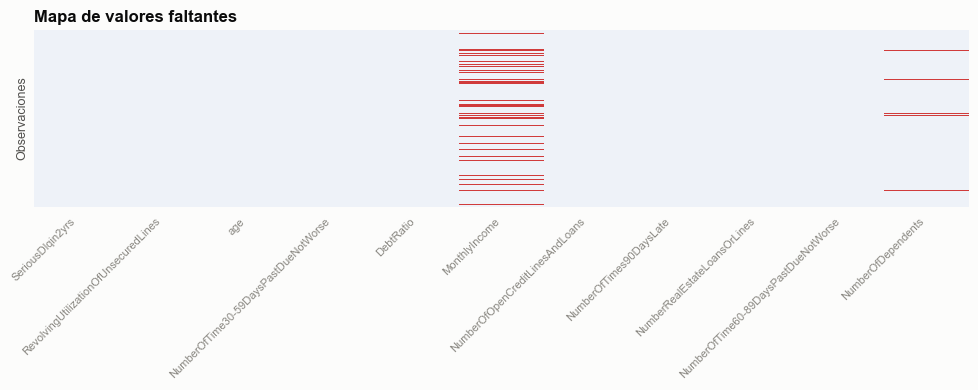

In [9]:
cmap_faltantes = ListedColormap(["#eef2f8", COLOR_CRITICAL])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap=cmap_faltantes, ax=ax)
ax.set_title("Mapa de valores faltantes", fontsize=12, color=PRIMARY_TEXT, fontweight="bold", loc="left")
ax.set_ylabel("Observaciones", fontsize=9, color=SECONDARY_TEXT)
ax.set_yticks([])
ax.tick_params(axis="x", colors=MUTED_TEXT, labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

El mapa de valores faltantes deja ver que casi todo el dataset está completo. Solo dos variables tienen nulos: `MonthlyIncome`, con un porcentaje considerable, y `NumberOfDependents`, con uno bajo. `MonthlyIncome` es clave para medir capacidad de pago y riesgo crediticio, así que eliminarla no es opción — voy a imputar con la mediana, porque los ingresos suelen venir con distribución asimétrica y ahí la mediana aguanta mejor los extremos que la media. `NumberOfDependents` tiene pocos nulos, pero por consistencia la imputo igual con mediana.

Antes de imputar `MonthlyIncome`, guardo un indicador (`ingreso_no_reportado`) de qué filas tenían el ingreso faltante. La imputación por mediana resuelve el problema de tener un valor numérico para modelar, pero **no resuelve** un problema distinto que aparece en la sección 3.4: para esas mismas filas, `DebtRatio` no se comporta como una razón (deuda/ingreso) sino como una cifra de deuda absoluta, precisamente porque el ingreso original no estaba disponible para calcularla como razón. El indicador permite documentar y tratar ese fenómeno explícitamente más adelante, en vez de dejar que la imputación oculte la causa.

In [10]:
# Flag ANTES de imputar: en la sección 3.4 se usa para explicar por qué DebtRatio > 1
# se concentra en los registros donde el ingreso no fue reportado.
df["ingreso_no_reportado"] = df["MonthlyIncome"].isna()

df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

**Corrección de `age == 0`:** en la sección 3.3 apareció un registro con `age == 0`. Lo elimino aquí, antes de seguir, con esta justificación formal:

- **Es lógicamente imposible dentro del dominio del negocio.** Nadie de 0 años solicita ni mantiene una línea de crédito, un historial de pagos o una calificación de riesgo — los productos financieros que describe este dataset (líneas revolventes, préstamos, hipotecas) requieren mayoría de edad legal. `age == 0` no es un valor extremo válido, es un error de captura.
- **El costo de eliminarlo es despreciable.** Es 1 fila de 150,000 (0.00067%). Ni el tamaño muestral ni la representatividad del dataset se ven afectados.
- **El costo de NO eliminarlo es alto.** Si se deja, distorsiona la media y el mínimo de `age` en los estadísticos descriptivos (3.1), sesga el eje de los histogramas y diagramas de caja (3.2–3.3) y, más importante, puede alterar artificialmente los diagnósticos de forma y las pruebas de Mann-Whitney de la sección 5: un valor tan extremo (0 años, muy por fuera del rango real de 21 a 109) infla la varianza y la asimetría de forma no representativa del fenómeno que se quiere medir.

Por estas tres razones — imposibilidad lógica, costo de eliminación insignificante, riesgo de distorsión aguas abajo — el tratamiento correcto es eliminar la fila, no imputarla (no hay un valor "razonable" para reemplazar una edad de 0 años) ni tratarla como un atípico legítimo.

In [11]:
n_antes = len(df)
df = df.loc[df["age"] > 0].copy()
print(f"Filas eliminadas por age == 0: {n_antes - len(df)}")
print(f"Filas restantes: {len(df):,}")

Filas eliminadas por age == 0: 1
Filas restantes: 149,999


In [12]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
ingreso_no_reportado                    0
dtype: int64

## 3. Análisis univariado

### 3.1 Estadísticos descriptivos

In [13]:
num_cols = [c for c in df.columns if c not in ["SeriousDlqin2yrs", "ingreso_no_reportado"]]

resumen_numericas = df[num_cols].describe().T
resumen_numericas["IQR"] = resumen_numericas["75%"] - resumen_numericas["25%"]
resumen_numericas = resumen_numericas.rename(columns={
    "50%": "mediana", "25%": "Q1", "75%": "Q3", "mean": "media", "std": "ds",
    "min": "minimo", "max": "maximo"
}).round(2)
resumen_numericas

,count,media,ds,minimo,Q1,mediana,Q3,maximo,IQR
RevolvingUtilizationOfUnsecuredLines,149999.0,6.05,249.76,0.0,0.03,0.15,0.56,50708.0,0.53
age,149999.0,52.30,14.77,21.0,41.00,52.00,63.00,109.0,22.00
NumberOfTime30-59DaysPastDueNotWorse,149999.0,0.42,4.19,0.0,0.00,0.00,0.00,98.0,0.00
DebtRatio,149999.0,353.01,2037.83,0.0,0.18,0.37,0.87,329664.0,0.69
MonthlyIncome,149999.0,6418.46,12890.44,0.0,3903.00,5400.00,7400.00,3008750.0,3497.00
NumberOfOpenCreditLinesAndLoans,149999.0,8.45,5.15,0.0,5.00,8.00,11.00,58.0,6.00
NumberOfTimes90DaysLate,149999.0,0.27,4.17,0.0,0.00,0.00,0.00,98.0,0.00
NumberRealEstateLoansOrLines,149999.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0,2.00
NumberOfTime60-89DaysPastDueNotWorse,149999.0,0.24,4.16,0.0,0.00,0.00,0.00,98.0,0.00
NumberOfDependents,149999.0,0.74,1.11,0.0,0.00,0.00,1.00,20.0,1.00


### 3.2 Distribución de las variables numéricas

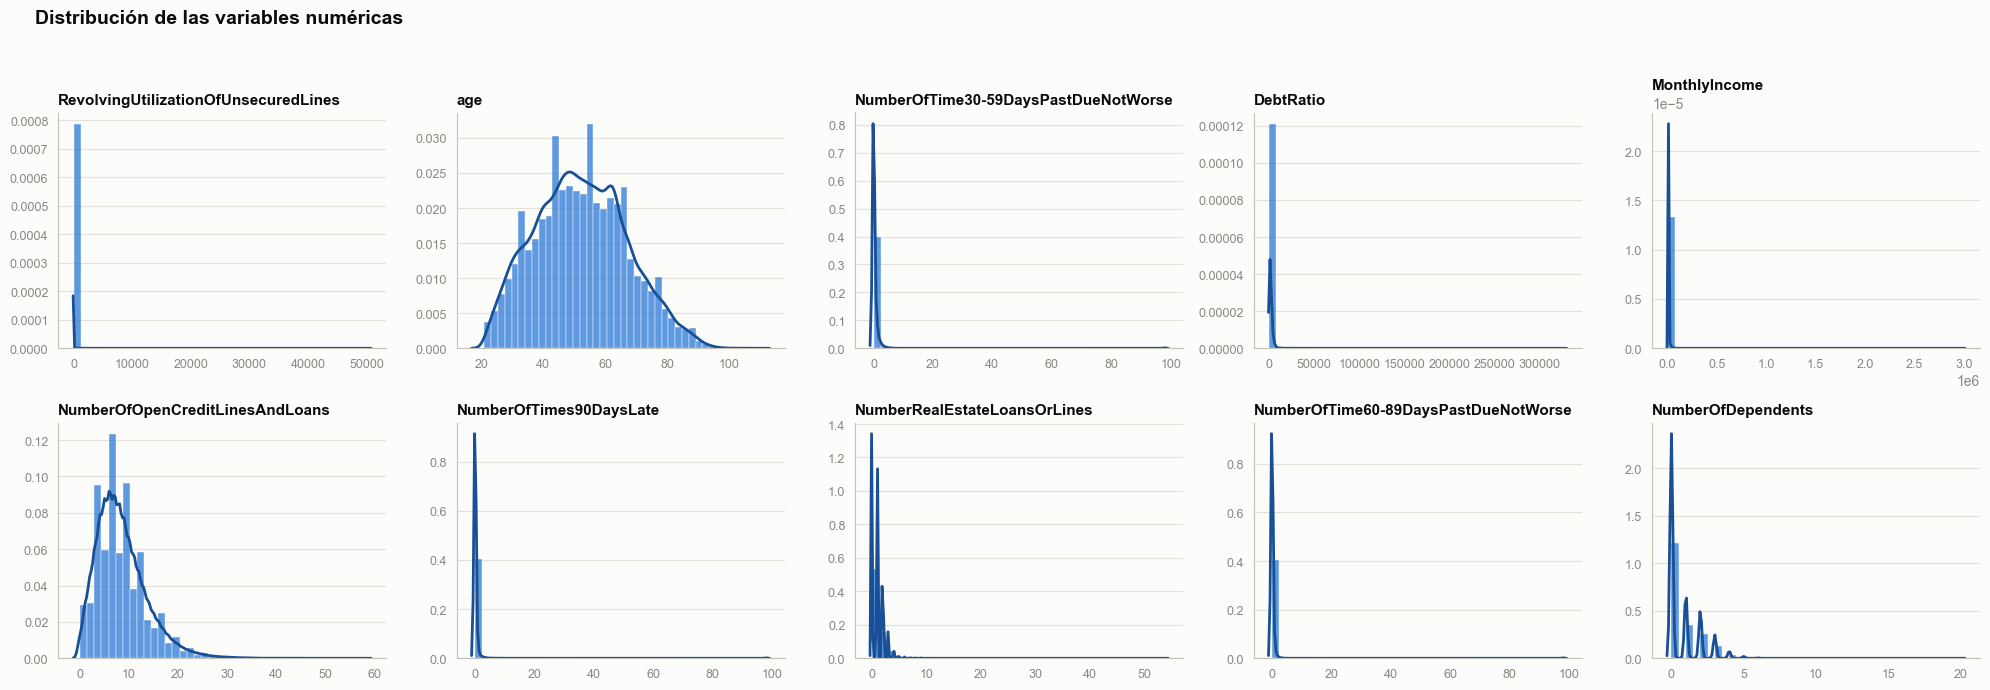

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, color=COLOR_SEQ, edgecolor="white", linewidth=0.3,
                 stat="density", ax=axes[i])
    sns.kdeplot(df[col], color=COLOR_SEQ_DARK, linewidth=2, ax=axes[i])
    style_ax(axes[i], title=col)
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribución de las variables numéricas", fontsize=14, color=PRIMARY_TEXT,
              fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

La mayoría de las variables tiene una asimetría positiva marcada, cola a la derecha. Se nota especialmente en `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` y `MonthlyIncome`: sus histogramas amontonan casi toda la masa cerca de cero y luego arrastran una cola larga de valores extremos. `age` es la única que se acerca a algo simétrico. Y las tres variables de conteo de atrasos (`NumberOfTime30-59`, `60-89` y `90 días`) concentran casi todo en cero, pero tienen un pico raro aislado en **96 y 98** — es un código de valor especial del dataset original, no un conteo real de atrasos.

In [15]:
diagnostico_forma_num = pd.DataFrame({
    "asimetria": df[num_cols].apply(stats.skew),
    "curtosis_exceso": df[num_cols].apply(stats.kurtosis),
    "n_unicos": df[num_cols].nunique(),
}).round(2)
diagnostico_forma_num

,asimetria,curtosis_exceso,n_unicos
RevolvingUtilizationOfUnsecuredLines,97.63,14544.13,125728
age,0.19,-0.50,85
NumberOfTime30-59DaysPastDueNotWorse,22.60,522.36,16
DebtRatio,95.16,13733.74,114193
MonthlyIncome,127.12,24260.82,13594
NumberOfOpenCreditLinesAndLoans,1.22,3.09,58
NumberOfTimes90DaysLate,23.09,537.72,19
NumberRealEstateLoansOrLines,3.48,60.48,28
NumberOfTime60-89DaysPastDueNotWorse,23.33,545.66,13
NumberOfDependents,1.63,3.14,13


La tabla cuantifica lo que el histograma sugiere visualmente, y es la base formal para descartar el supuesto de normalidad en toda la sección 5 (sin recurrir a pruebas de bondad de ajuste — ver la nota metodológica al inicio de esa sección):

- **Asimetría (skewness) fuertemente positiva** en `RevolvingUtilizationOfUnsecuredLines` (≈98), `MonthlyIncome` (≈127) y `DebtRatio` (≈95): valores muy por encima de los umbrales convencionales (|asimetría| > 1 ya se considera alta), reflejo de la cola derecha larga que se ve en los histogramas.
- **Curtosis en exceso extrema** en esas mismas variables (del orden de miles) y en las tres variables de conteo de atrasos (cientos): colas muchísimo más pesadas que una normal, con masa concentrada en un valor (típicamente 0) y unos pocos valores extremos aislados — exactamente lo que se espera de una mezcla entre un conteo discreto y un código de valor especial (96/98, tratado formalmente en 3.4).
- **Naturaleza discreta / de conteo**: `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines` y `NumberOfDependents` tienen muy pocos valores únicos (entre 13 y 58 sobre 150,000 observaciones): son conteos enteros no negativos, no magnitudes continuas, así que un modelo de densidad normal (continua, simétrica, de soporte infinito) no describe su proceso generador por construcción, sin importar qué diga cualquier prueba formal.
- `age` es la variable más cercana a la simetría (asimetría ≈ 0.19, curtosis en exceso ≈ -0.50, ligeramente platicúrtica), pero sigue siendo un conteo discreto en años completos (85 valores únicos) con soporte acotado — no hay ninguna variable en este dataset razonablemente modelable como normal continua.

Esta evidencia — asimetría, curtosis, discreción y colas pesadas — es la que sostiene, de aquí en adelante, la decisión de usar estadísticos y pruebas no paramétricas (mediana, Mann-Whitney U, correlación de Spearman) en vez de sus contrapartes paramétricas.

### 3.3 Detección de valores atípicos

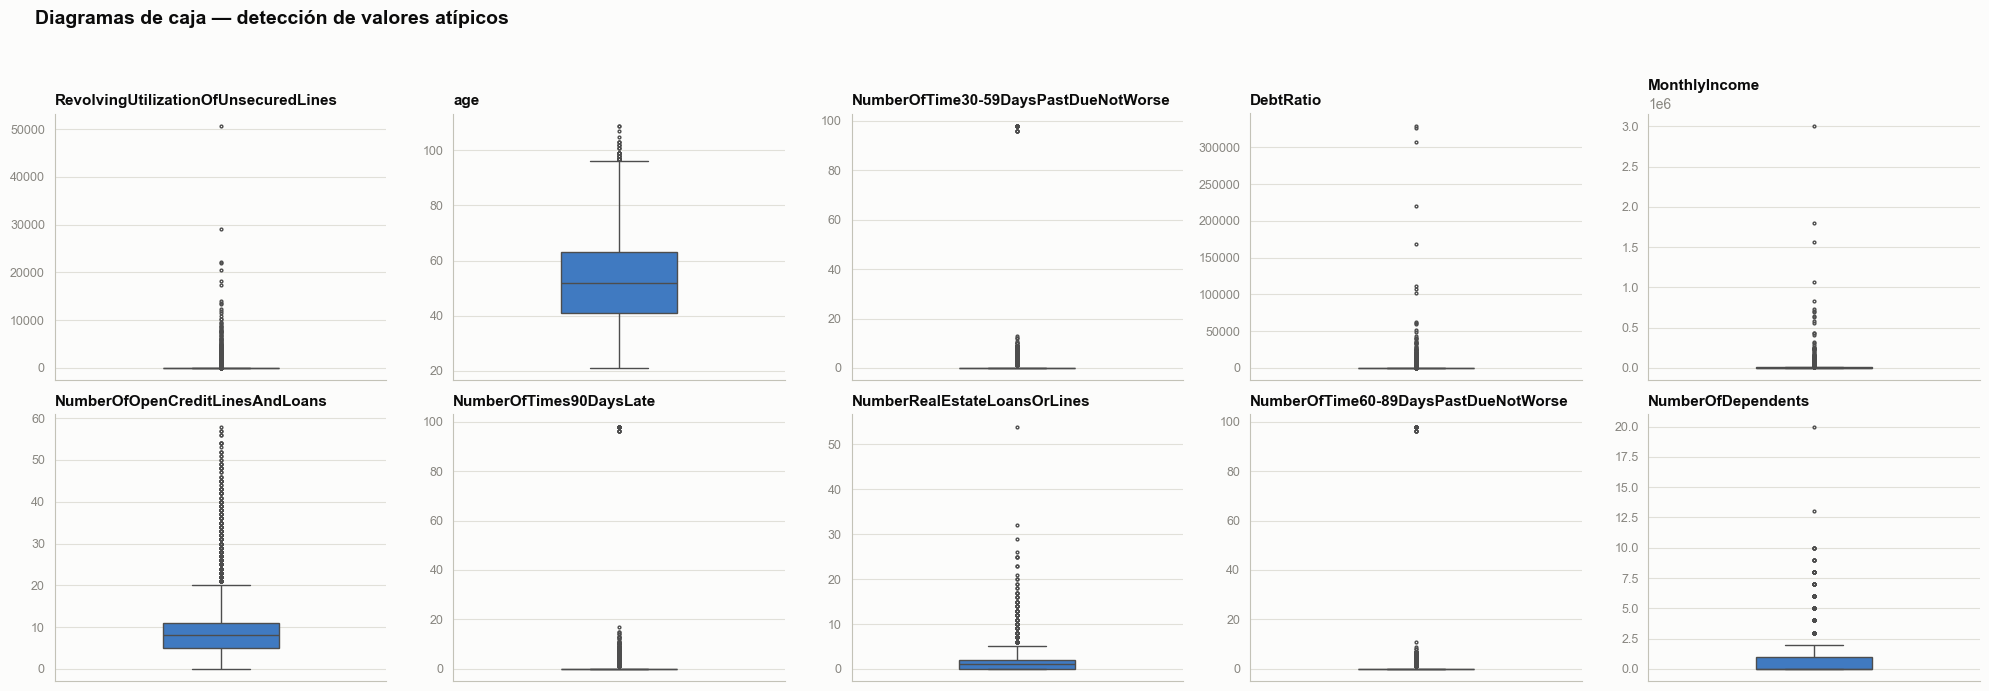

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=COLOR_SEQ, width=0.35, fliersize=2, linewidth=1)
    style_ax(axes[i], title=col)
    axes[i].set_ylabel("")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Diagramas de caja — detección de valores atípicos", fontsize=14, color=PRIMARY_TEXT,
              fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

El análisis de estadísticos descriptivos muestra la presencia de valores atípicos severos en varias variables. Las tres relacionadas con historial de atrasos (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) tienen una desviación estándar bastante más alta que su media, y su percentil 75 es 0 mientras el máximo llega a 98 — otra vez el código de valor especial (98/96), no atrasos reales.

`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` y `MonthlyIncome` van por otro lado: sus máximos quedan lejísimos de la mediana, lo que apunta a errores de captura o casos atípicos genuinos que hay que tratar antes de modelar.

Y está `age`, con un mínimo de 0 años. Nadie de cero años pide un crédito, así que es un error de captura que hay que corregir.

### 3.4 Tratamiento de anomalías antes del bivariado: códigos especiales de mora (96/98) y `DebtRatio` elevado

Las secciones 3.2 y 3.3 detectaron un patrón inusual en las tres variables de conteo de atrasos (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`): un pico aislado en los valores **96 y 98**, muy lejos del resto de la distribución (que va de 0 a poco más de una decena de atrasos reales). Este es un problema documentado del dataset original de Kaggle: 96 y 98 son **códigos de valor especial** (*sentinel values*) — no representan 96 o 98 atrasos reales de un cliente, sino alguna condición particular del proceso de captura (por ejemplo, cuentas sin historial suficiente para contar atrasos).

Antes de calcular cualquier estadístico descriptivo, mediana por grupo, prueba de hipótesis o correlación con estas variables, hay que tratar estos códigos — de lo contrario, contaminan la mediana, inflan artificialmente la varianza/asimetría, y distorsionan tanto el análisis bivariado (sección 4) como la comparación de grupos (sección 5) y la matriz de correlación (sección 6).

In [17]:
mora_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

codigos_especiales_mora = df[mora_cols].isin([96, 98]).any(axis=1)
print(f"Filas con código especial (96 o 98) en al menos una variable de mora: "
      f"{codigos_especiales_mora.sum()} ({codigos_especiales_mora.mean()*100:.3f}%)")

df["flag_codigo_especial_mora"] = codigos_especiales_mora

for col in mora_cols:
    df[col] = df[col].where(~df[col].isin([96, 98]))

df[mora_cols].isnull().sum().rename("n_tratados_como_nan")

Filas con código especial (96 o 98) en al menos una variable de mora: 269 (0.179%)


NumberOfTime30-59DaysPastDueNotWorse    269
NumberOfTime60-89DaysPastDueNotWorse    269
NumberOfTimes90DaysLate                 269
Name: n_tratados_como_nan, dtype: int64

**Tratamiento aplicado en este EDA:** de aquí en adelante, los tres campos de mora tienen los valores 96/98 reemplazados temporalmente por `NaN`. Es un tratamiento **provisional, solo para que los estadísticos descriptivos (medianas, sección 4), las pruebas de hipótesis (Mann-Whitney U, sección 5) y la matriz de correlación de Spearman (sección 6) no queden contaminados** por un valor que no es un conteo real. Todas las comparaciones de grupo y correlaciones de aquí en adelante excluyen estas filas de forma *pairwise* (columna por columna), no *listwise* — no se elimina la fila completa del dataset, solo se excluye de los cálculos que usan esa variable puntual.

**Estrategia recomendada para la fase de modelado** (no se aplica aún en este notebook, que es exploratorio):

1. **Dummy/indicador explícito**: conservar `flag_codigo_especial_mora` (ya creado arriba) como variable binaria de entrada al modelo. Si el código especial está correlacionado con el riesgo de mora — algo plausible, dado que probablemente refleja clientes sin historial de crédito suficiente — esta bandera captura esa señal en lugar de perderla.
2. **Imputación explícita y documentada** de los valores tratados como `NaN`: la mediana (0, dado que la enorme mayoría de valores legítimos son 0) es razonable como valor por defecto, siempre que la bandera del punto 1 acompañe a la variable imputada, para no perder la distinción entre "cero atrasos reales" y "código especial reemplazado por 0".
3. Alternativamente, si el modelo es de árboles (Random Forest, Gradient Boosting), se puede dejar el código especial **sin tratar** (como 96/98) y dejar que el árbol lo aísle como una rama propia — estos modelos no asumen una escala continua y pueden aprovechar el valor atípico como señal en vez de ruido. Esa decisión se toma en la fase de modelado, no en el EDA.

### Anomalía en `DebtRatio`: valores muy por encima de 1

La sección 3.3 ya señaló que `DebtRatio` tiene un máximo (329,664) absurdo para ser una razón deuda/ingreso — una razón de ese orden no tiene interpretación financiera plausible. Antes de asumir que son simplemente "atípicos genuinos", vale la pena entender **por qué** pasa esto.

`DebtRatio` se define como pagos mensuales de deuda ÷ ingreso mensual. El fenómeno se explica por el denominador: en el 19.8% de las filas donde `MonthlyIncome` venía originalmente en blanco (bandera `ingreso_no_reportado`, creada en la sección 2.3, antes de imputar), `DebtRatio` no pudo haberse calculado como una razón real — no había ingreso con el que dividir. La tabla de abajo lo confirma: entre esas filas, el 93.9% tiene `DebtRatio` > 1 (mediana ≈ 1,159), mientras que entre las filas con ingreso sí reportado, solo el 6% supera 1 (mediana ≈ 0.30, un valor perfectamente razonable para una razón deuda/ingreso). En otras palabras: cuando el ingreso no estaba disponible, lo que aparece en la columna `DebtRatio` es, con toda probabilidad, **el pago de deuda absoluto** (en dólares), no una razón — y la imputación de `MonthlyIncome` por la mediana (sección 2.3) no corrige este problema, porque no recalcula `DebtRatio` con el nuevo ingreso imputado; solo asegura que el ingreso no quede nulo.

In [18]:
resumen_debtratio = df.groupby("ingreso_no_reportado")["DebtRatio"].agg(
    n="count", pct_mayor_a_1=lambda s: (s > 1).mean() * 100, mediana="median"
).round(2)
resumen_debtratio

,n,pct_mayor_a_1,mediana
ingreso_no_reportado,,,
False,120268,6.01,0.3
True,29731,93.85,1159.0


**Implicación para el EDA y para el modelado:**

- En este notebook no filtro ni transformo `DebtRatio` — el objetivo del EDA es documentar el fenómeno, no corregirlo prematuramente — pero sí queda registrado que la variable **no es homogénea**: mezcla dos poblaciones con significados distintos (razón real vs. cifra de deuda absoluta "disfrazada" de razón).
- Para el modelado, la recomendación es **segmentar o transformar explícitamente**, por ejemplo:
  - Usar `ingreso_no_reportado` como variable de segmentación o de interacción, para que el modelo no trate ambos subgrupos como si vinieran del mismo proceso.
  - Aplicar una transformación robusta a la escala (log1p, winsorización o directamente el uso de rangos/percentiles) que reduzca el peso desproporcionado de los valores extremos sin necesidad de decidir, fila por fila, cuál es "razón real" y cuál es "deuda absoluta".
  - Como mínimo, evitar cualquier método de escalado sensible a la media/varianza (p. ej. `StandardScaler` sin transformación previa) mientras esta mezcla no se resuelva, porque la varianza de `DebtRatio` está dominada por estos valores extremos.

### 3.5 Variable objetivo

In [19]:
tabla_target = df["SeriousDlqin2yrs"].value_counts().sort_index().reset_index()
tabla_target.columns = ["SeriousDlqin2yrs", "n"]
tabla_target["porcentaje"] = round(tabla_target["n"] / tabla_target["n"].sum() * 100, 2)
tabla_target

,SeriousDlqin2yrs,n,porcentaje
0,0,139973,93.32
1,1,10026,6.68


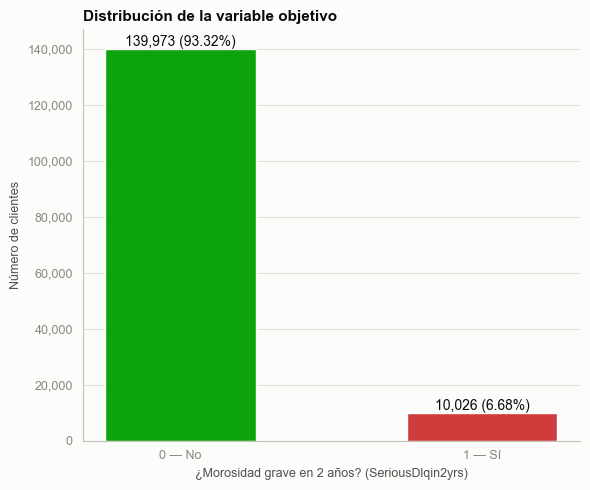

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = [COLOR_GOOD, COLOR_CRITICAL]
bars = ax.bar(tabla_target["SeriousDlqin2yrs"].astype(str), tabla_target["n"],
              color=colors, width=0.5, zorder=3)

for bar, row in zip(bars, tabla_target.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{row.n:,} ({row.porcentaje}%)", ha="center", va="bottom",
            fontsize=10, color=PRIMARY_TEXT)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 — No", "1 — Sí"])
style_ax(ax, title="Distribución de la variable objetivo",
         xlabel="¿Morosidad grave en 2 años? (SeriousDlqin2yrs)", ylabel="Número de clientes")
plt.tight_layout()
plt.show()

Hay un desbalance de clases marcado: **93.32%** de los clientes (139,974) no presentó morosidad grave, frente a solo **6.68%** (10,026) que sí. Tiene sentido — los incumplimientos graves, por definición, no son lo común — pero hay que tenerlo presente al modelar, ya sea con remuestreo, ponderación de clases o mirando métricas distintas a la exactitud, como AUC o recall.

## 4. Análisis bivariado

Para el bivariado elijo ocho variables numéricas y las comparo contra la variable objetivo con diagramas de caja, marcando la media de cada grupo con un punto. Incluyo las cinco variables de interés de negocio originales (`age`, `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome`, `NumberOfOpenCreditLinesAndLoans`) más las tres variables de conteo de atrasos — que en la sección 3.4 quedaron con los códigos especiales 96/98 tratados como `NaN` —, ya que son, a priori, algunas de las variables más relevantes para el riesgo de crédito y no hay ya ninguna razón para excluirlas. Dejo fuera únicamente `NumberRealEstateLoansOrLines` y `NumberOfDependents`, por ser de menor interés de negocio directo para este análisis, no por ningún problema de calidad de datos.

In [21]:
bivar_vars = [
    "age",
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

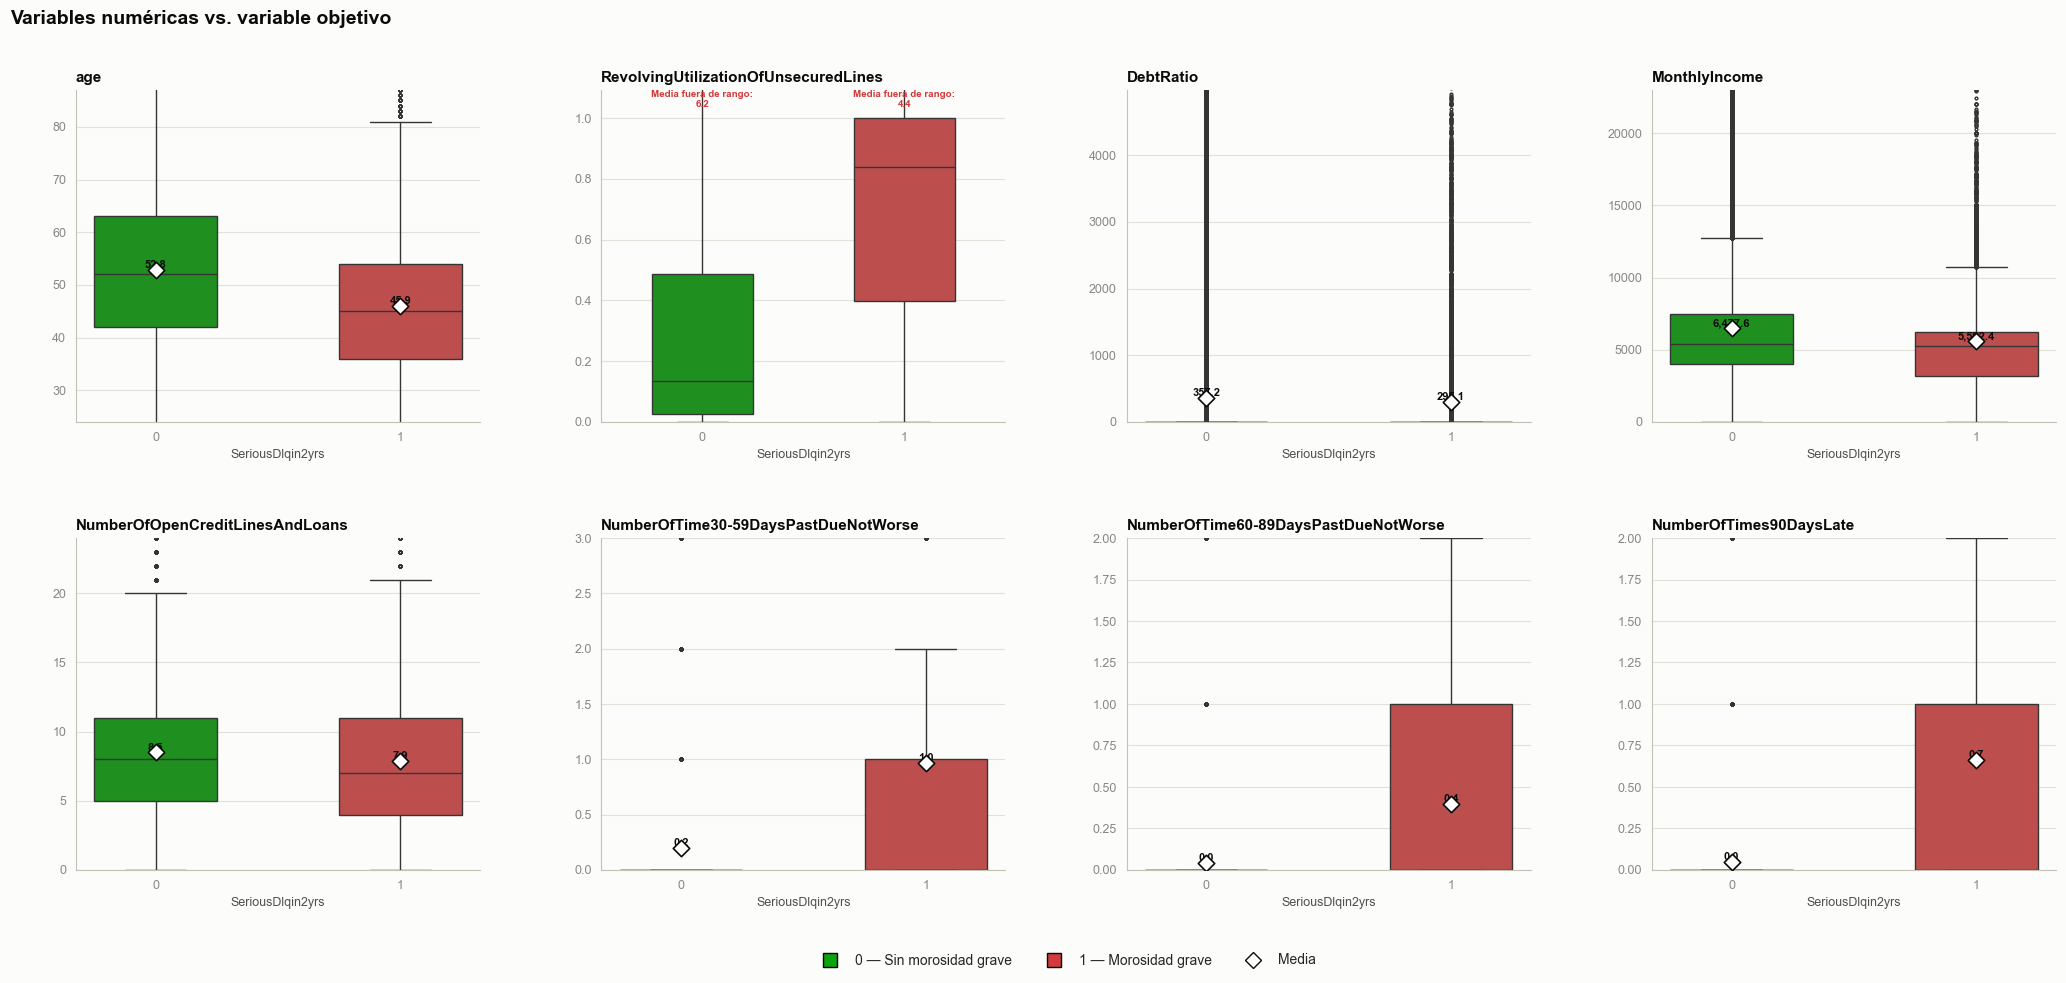

In [22]:
n_vars = len(bivar_vars)
n_columnas = 4
n_filas = int(np.ceil(n_vars / n_columnas))

fig, axes = plt.subplots(n_filas, n_columnas, figsize=(5.5 * n_columnas, 5 * n_filas))
axes = axes.flatten()

for i, col in enumerate(bivar_vars):
    datos = df[["SeriousDlqin2yrs", col]].dropna()
    sns.boxplot(data=datos, x="SeriousDlqin2yrs", y=col, hue="SeriousDlqin2yrs",
                palette=[COLOR_GOOD, COLOR_CRITICAL], width=0.5, fliersize=2,
                linewidth=1, legend=False, ax=axes[i])

    # 1. Definir los límites del eje primero
    lo, hi = datos[col].quantile([0.01, 0.99])
    if lo == hi:
        lo, hi = datos[col].min(), datos[col].max() + 1
    axes[i].set_ylim(lo, hi)

    # 2. Calcular medias
    medias = datos.groupby("SeriousDlqin2yrs", observed=True)[col].mean()

    # 3. Dibujar punto y texto SOLO si la media está dentro del rango visible (lo, hi)
    for x, val in enumerate(medias.values):
        if lo <= val <= hi:
            axes[i].scatter(x, val, marker="D", s=70, color="white",
                            edgecolor=PRIMARY_TEXT, linewidth=1.2, zorder=5)
            axes[i].text(x, val, f"{val:,.1f}", ha="center", va="bottom",
                         fontsize=8, color=PRIMARY_TEXT, fontweight="bold")
        else:
            # Si la media está fuera por outliers, se muestra arriba como anotación
            axes[i].text(x, hi, f"Media fuera de rango:\n{val:,.1f}", ha="center", va="top",
                         fontsize=7, color=COLOR_CRITICAL, fontweight="bold")

    style_ax(axes[i], title=col, xlabel="SeriousDlqin2yrs")
    axes[i].set_ylabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0", "1"])

for j in range(len(bivar_vars), len(axes)):
    axes[j].axis("off")

legend_elems = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_GOOD, markersize=10,
           label="0 — Sin morosidad grave"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_CRITICAL, markersize=10,
           label="1 — Morosidad grave"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="white",
           markeredgecolor=PRIMARY_TEXT, markersize=8, label="Media"),
]

# Ajuste de layout manual para evitar el UserWarning de tight_layout
fig.suptitle("Variables numéricas vs. variable objetivo", fontsize=14, color=PRIMARY_TEXT,
             fontweight="bold", x=0.02, ha="left")
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.01))

plt.subplots_adjust(top=0.9, bottom=0.12, left=0.05, right=0.95, hspace=0.35, wspace=0.3)
plt.show()

In [23]:
resumen_bivar = df.groupby("SeriousDlqin2yrs", observed=True)[bivar_vars].median().T
resumen_bivar.columns = ["mediana_0", "mediana_1"]
resumen_bivar["diferencia_%"] = round(
    (resumen_bivar["mediana_1"] - resumen_bivar["mediana_0"])
    / resumen_bivar["mediana_0"].replace(0, np.nan) * 100, 1
)
resumen_bivar

,mediana_0,mediana_1,diferencia_%
age,52.000000,45.000000,-13.5
RevolvingUtilizationOfUnsecuredLines,0.133287,0.838853,529.4
DebtRatio,0.362659,0.428227,18.1
MonthlyIncome,5400.000000,5240.000000,-3.0
NumberOfOpenCreditLinesAndLoans,8.000000,7.000000,-12.5
NumberOfTime30-59DaysPastDueNotWorse,0.000000,0.000000,NaN
NumberOfTime60-89DaysPastDueNotWorse,0.000000,0.000000,NaN
NumberOfTimes90DaysLate,0.000000,0.000000,NaN


La tabla compara, variable por variable, la mediana entre clientes sin morosidad grave (0) y con morosidad grave (1) — las tres variables de mora ya usan los valores tratados en 3.4 (96/98 como `NaN`, excluidos del cálculo). Si la diferencia porcentual es grande, la variable separa bien ambos grupos y pinta como candidata a tener poder predictivo; si está cerca de 0%, aparentemente no dice mucho por sí sola.

**Nota:** para las tres variables de mora la mediana de ambos grupos es 0 (la mayoría de los clientes, con o sin morosidad grave, no registra atrasos), así que la diferencia porcentual no es informativa ahí — la mediana no alcanza a distinguir esos grupos, aunque sí exista una diferencia real más arriba en la distribución (colas), que es justamente lo que Mann-Whitney U, en la sección 5, sí puede detectar. Cuáles diferencias son estadísticamente significativas de verdad — y qué tan grandes en términos prácticos — lo confirma la sección 5.

## 5. Comparación de grupos según la variable objetivo

Esta sección compara la distribución de cada variable numérica entre los dos niveles de la variable objetivo (`SeriousDlqin2yrs` = 0 y 1).

**Por qué no uso pruebas formales de normalidad como criterio de decisión.** Con un tamaño muestral de N ≈ 150,000 (y subgrupos de decenas de miles de observaciones cada uno), cualquier prueba formal de bondad de ajuste — Kolmogorov-Smirnov, Shapiro-Wilk, Lilliefors — sufre de **exceso de potencia estadística**: al crecer N, la potencia de la prueba tiende a 1, y el test termina rechazando la hipótesis nula de normalidad ante desviaciones triviales, sin relevancia práctica, que ni siquiera se distinguen a simple vista en un histograma. Confirmarlo empíricamente no aporta nada — a este tamaño de muestra, prácticamente cualquier variable real "reprueba" un test de normalidad. Por esa razón, este notebook **no ejecuta pruebas formales de normalidad** (se retiró Lilliefors, junto con la dependencia de `statsmodels` que solo se usaba para eso) y en su lugar apoya la decisión metodológica en diagnósticos descriptivos: asimetría (skewness), curtosis, naturaleza discreta (conteos) y colas pesadas, ya calculados en la sección 3.2 (ver 5.1).

Con base en esos diagnósticos, aplico **Mann-Whitney U** de manera uniforme a las ocho variables seleccionadas para el análisis bivariado, sin un árbol de decisión condicionado a normalidad/homocedasticidad. Por la misma razón (exceso de potencia a este N) tampoco uso la prueba de Levene para decidir entre t de Student y t de Welch — la sección 5.2 compara la dispersión entre grupos de forma puramente descriptiva, no con otra prueba de hipótesis.

`SeriousDlqin2yrs` tiene exactamente dos niveles, así que no hace falta corrección por comparaciones múltiples ni prueba post-hoc: solo existe una comparación posible entre los dos grupos.

### 5.1 Diagnóstico descriptivo de forma (no pruebas formales de normalidad)

In [24]:
def diagnostico_forma(x):
    """Asimetria, curtosis en exceso y n. de valores unicos, sin pruebas formales de bondad de ajuste."""
    x = x.dropna()
    return pd.Series({
        "n": len(x),
        "asimetria": stats.skew(x),
        "curtosis_exceso": stats.kurtosis(x),
        "n_unicos": x.nunique(),
    })


filas_forma = []
for col in bivar_vars:
    for grupo in [0, 1]:
        x = df.loc[df["SeriousDlqin2yrs"] == grupo, col]
        resultado = diagnostico_forma(x).to_dict()
        resultado.update({"variable": col, "grupo": grupo})
        filas_forma.append(resultado)

diagnostico_forma_grupos = pd.DataFrame(filas_forma)[
    ["variable", "grupo", "n", "asimetria", "curtosis_exceso", "n_unicos"]
]
diagnostico_forma_grupos.round(3)

,variable,grupo,n,asimetria,curtosis_exceso,n_unicos
0,age,0,139973.0,0.164,-0.507,85.0
1,age,1,10026.0,0.458,0.023,76.0
2,RevolvingUtilizationOfUnsecuredLines,0,139973.0,96.569,14080.149,118380.0
3,RevolvingUtilizationOfUnsecuredLines,1,10026.0,44.915,2312.165,7698.0
4,DebtRatio,0,139973.0,95.270,13471.406,106784.0
5,DebtRatio,1,10026.0,11.111,219.711,9263.0
6,MonthlyIncome,0,139973.0,125.134,23238.794,13380.0
7,MonthlyIncome,1,10026.0,18.230,657.712,3102.0
8,NumberOfOpenCreditLinesAndLoans,0,139973.0,1.223,3.085,58.0
9,NumberOfOpenCreditLinesAndLoans,1,10026.0,1.194,3.112,47.0


In [25]:
print(
    "Las ocho variables muestran asimetria marcada, colas pesadas o son conteos discretos con pocos "
    "valores unicos y masa concentrada en 0 (ver tabla arriba y la seccion 3.2). Ninguna es "
    "razonablemente modelable como normal continua, en ningun grupo. Con un N por grupo de decenas de "
    "miles de observaciones, ejecutar ademas una prueba formal de normalidad no cambiaria esta "
    "conclusion -- a ese tamano de muestra, la prueba rechazaria normalidad en practicamente cualquier "
    "variable real, incluso ante desviaciones sin relevancia practica (exceso de potencia). Por eso, "
    "de aqui en adelante, aplico Mann-Whitney U de manera uniforme a las ocho variables, sin un arbol "
    "de decision condicionado a un resultado de normalidad."
)

Las ocho variables muestran asimetria marcada, colas pesadas o son conteos discretos con pocos valores unicos y masa concentrada en 0 (ver tabla arriba y la seccion 3.2). Ninguna es razonablemente modelable como normal continua, en ningun grupo. Con un N por grupo de decenas de miles de observaciones, ejecutar ademas una prueba formal de normalidad no cambiaria esta conclusion -- a ese tamano de muestra, la prueba rechazaria normalidad en practicamente cualquier variable real, incluso ante desviaciones sin relevancia practica (exceso de potencia). Por eso, de aqui en adelante, aplico Mann-Whitney U de manera uniforme a las ocho variables, sin un arbol de decision condicionado a un resultado de normalidad.


### 5.2 Diferencias de dispersión entre grupos (diagnóstico descriptivo)

Antes de interpretar Mann-Whitney U, reviso si la dispersión (variabilidad) de cada variable es parecida entre los dos grupos. Esto **no es una prueba de hipótesis** — evito repetir aquí el mismo problema de exceso de potencia de Levene a N ≈ 150,000 — sino una comparación puramente descriptiva de la desviación estándar y el rango intercuartílico (IQR) por grupo.

Sirve para anticipar cómo leer el resultado de Mann-Whitney en 5.3: si la dispersión difiere notablemente entre grupos, un resultado significativo refleja **dominancia estocástica general** (la distribución completa de un grupo tiende a estar desplazada o tiene una forma distinta a la del otro), no una diferencia limpia solo en la mediana con todo lo demás igual.

In [26]:
filas_dispersion = []
for col in bivar_vars:
    g0 = df.loc[df["SeriousDlqin2yrs"] == 0, col].dropna()
    g1 = df.loc[df["SeriousDlqin2yrs"] == 1, col].dropna()
    filas_dispersion.append({
        "variable": col,
        "std_0": g0.std(), "std_1": g1.std(),
        "iqr_0": g0.quantile(0.75) - g0.quantile(0.25),
        "iqr_1": g1.quantile(0.75) - g1.quantile(0.25),
        "razon_std_1_vs_0": g1.std() / g0.std() if g0.std() > 0 else np.nan,
    })

dispersion_grupos = pd.DataFrame(filas_dispersion)
dispersion_grupos.round(3)

,variable,std_0,std_1,iqr_0,iqr_1,razon_std_1_vs_0
0,age,14.790,12.916,21.000,18.000,0.873
1,RevolvingUtilizationOfUnsecuredLines,256.127,131.836,0.461,0.602,0.515
2,DebtRatio,2083.289,1238.360,0.692,0.698,0.594
3,MonthlyIncome,13256.646,5635.258,3500.000,3000.000,0.425
4,NumberOfOpenCreditLinesAndLoans,5.105,5.654,6.000,7.000,1.107
5,NumberOfTime30-59DaysPastDueNotWorse,0.593,1.356,0.000,1.000,2.285
6,NumberOfTime60-89DaysPastDueNotWorse,0.248,0.811,0.000,1.000,3.266
7,NumberOfTimes90DaysLate,0.333,1.286,0.000,1.000,3.865


### 5.3 Aplicación de Mann-Whitney U y tamaño de efecto

Aplico Mann-Whitney U a las ocho variables. Como se vio en 5.1 y 5.2, las formas (asimetría, colas, dispersión) difieren entre clientes con y sin morosidad grave en varias variables — no es un simple corrimiento de ubicación con todo lo demás igual. Por eso interpreto Mann-Whitney U como una prueba de **dominancia estocástica** (¿los valores de un grupo tienden a ser sistemáticamente mayores o menores que los del otro?), y no como un simple contraste de medianas.

Con N ≈ 150,000, prácticamente cualquier diferencia real, por pequeña que sea, resulta en p < 0.001 — el p-valor por sí solo no dice si la diferencia importa en la práctica. Por eso calculo, junto al p-valor, dos medidas de tamaño de efecto:

- **r de Rosenthal** (r = |Z| / √N, corregido por empates): mide qué tan lejos está el resultado de lo esperado bajo H0, en una escala comparable a una correlación (0 = sin efecto, ~0.5+ = efecto grande).
- **AUC univariado** (= P(valor en grupo 1 > valor en grupo 0)): la probabilidad de que, tomando un cliente al azar de cada grupo, el de morosidad grave tenga un valor más alto en esa variable. 0.5 = la variable no discrimina; más lejos de 0.5 (por arriba o por abajo) = mejor discrimina — un valor bien por debajo de 0.5 significa que el grupo con morosidad grave tiende a tener valores más *bajos*, no más altos.

In [27]:
def r_mann_whitney(x0, x1, u_stat):
    """Tamaño de efecto r = |Z| / sqrt(N), con Z a partir de U y sigma_U CORREGIDO por empates.

    La formula clasica sigma_u = sqrt(n0*n1*(n0+n1+1)/12) asume ausencia de empates. Con
    variables discretas o con mucha masa en el mismo valor (age, NumberOfOpenCreditLinesAndLoans,
    los ceros de DebtRatio/RevolvingUtilizationOfUnsecuredLines, y los ceros de las variables de
    mora) hay empates masivos, lo que infla sigma_u y por tanto subestima |Z| y el tamano de efecto
    si no se corrige. La correccion estandar (Hogg & Craig / Lehmann) resta un termino basado en
    el conteo de cada grupo de empates a partir de los rangos combinados de ambas muestras.
    """
    n0, n1 = len(x0), len(x1)
    n = n0 + n1

    combinado = np.concatenate([x0, x1])
    _, conteos_empates = np.unique(combinado, return_counts=True)

    correccion_empates = np.sum(conteos_empates ** 3 - conteos_empates) / (n * (n - 1))

    mu_u = n0 * n1 / 2
    sigma_u = np.sqrt((n0 * n1 / 12) * ((n + 1) - correccion_empates))

    z = (u_stat - mu_u) / sigma_u
    return abs(z) / np.sqrt(n)


def etiqueta_r(r):
    if r < 0.10:
        return "trivial"
    elif r < 0.30:
        return "pequeño"
    elif r < 0.50:
        return "mediano"
    return "grande"


filas_comparacion = []
for col in bivar_vars:
    datos = df[["SeriousDlqin2yrs", col]].dropna()
    grupo_0 = datos.loc[datos["SeriousDlqin2yrs"] == 0, col]
    grupo_1 = datos.loc[datos["SeriousDlqin2yrs"] == 1, col]
    n0, n1 = len(grupo_0), len(grupo_1)

    # U1: estadistico de Mann-Whitney para el grupo 1 (mayor U1 => valores de grupo_1 tienden a ser mas altos)
    estadistico_u1, p_val = stats.mannwhitneyu(grupo_1, grupo_0, alternative="two-sided")
    r_efecto = r_mann_whitney(grupo_0, grupo_1, estadistico_u1)
    auc = estadistico_u1 / (n0 * n1)

    filas_comparacion.append({
        "variable": col, "n_valido": n0 + n1, "estadistico_U1": estadistico_u1, "p_valor": p_val,
        "dif_significativa_5pct": p_val < 0.05,
        "r_rosenthal": r_efecto, "tamano_efecto_r": etiqueta_r(r_efecto),
        "auc_univariado": auc,
    })

resultados_comparacion = pd.DataFrame(filas_comparacion)
resultados_comparacion.round(4)

,variable,n_valido,estadistico_U1,p_valor,dif_significativa_5pct,r_rosenthal,tamano_efecto_r,auc_univariado
0,age,149999,5.118709e+08,0.0,True,0.1170,pequeño,0.3647
1,RevolvingUtilizationOfUnsecuredLines,149999,1.091478e+09,0.0,True,0.2404,pequeño,0.7778
2,DebtRatio,149999,7.350953e+08,0.0,True,0.0206,trivial,0.5238
3,MonthlyIncome,149999,6.020107e+08,0.0,True,0.0617,trivial,0.4290
4,NumberOfOpenCreditLinesAndLoans,149999,6.392331e+08,0.0,True,0.0386,trivial,0.4555
5,NumberOfTime30-59DaysPastDueNotWorse,149730,9.471095e+08,0.0,True,0.2514,pequeño,0.6855
6,NumberOfTime60-89DaysPastDueNotWorse,149730,8.519574e+08,0.0,True,0.2683,pequeño,0.6167
7,NumberOfTimes90DaysLate,149730,9.015918e+08,0.0,True,0.3354,mediano,0.6526


### 5.4 Síntesis

In [28]:
resultados_ordenados = resultados_comparacion.sort_values("r_rosenthal", ascending=False)

for fila in resultados_ordenados.itertuples():
    interpretacion = (
        "estadísticamente significativa, pero de tamaño de efecto TRIVIAL — no relevante en la práctica"
        if fila.tamano_efecto_r == "trivial" else
        f"estadísticamente significativa y de tamaño de efecto {fila.tamano_efecto_r.upper()}"
    )
    print(
        f"'{fila.variable}': {interpretacion} "
        f"(Mann-Whitney U, p={fila.p_valor:.2e}, r={fila.r_rosenthal:.3f}, AUC={fila.auc_univariado:.3f})."
    )

'NumberOfTimes90DaysLate': estadísticamente significativa y de tamaño de efecto MEDIANO (Mann-Whitney U, p=0.00e+00, r=0.335, AUC=0.653).
'NumberOfTime60-89DaysPastDueNotWorse': estadísticamente significativa y de tamaño de efecto PEQUEÑO (Mann-Whitney U, p=0.00e+00, r=0.268, AUC=0.617).
'NumberOfTime30-59DaysPastDueNotWorse': estadísticamente significativa y de tamaño de efecto PEQUEÑO (Mann-Whitney U, p=0.00e+00, r=0.251, AUC=0.686).
'RevolvingUtilizationOfUnsecuredLines': estadísticamente significativa y de tamaño de efecto PEQUEÑO (Mann-Whitney U, p=0.00e+00, r=0.240, AUC=0.778).
'age': estadísticamente significativa y de tamaño de efecto PEQUEÑO (Mann-Whitney U, p=0.00e+00, r=0.117, AUC=0.365).
'MonthlyIncome': estadísticamente significativa, pero de tamaño de efecto TRIVIAL — no relevante en la práctica (Mann-Whitney U, p=3.48e-126, r=0.062, AUC=0.429).
'NumberOfOpenCreditLinesAndLoans': estadísticamente significativa, pero de tamaño de efecto TRIVIAL — no relevante en la práctic

**Síntesis:** las ocho variables resultan estadísticamente significativas (p < 0.001) — es exactamente lo que se espera a N ≈ 150,000, y por eso el p-valor no es el criterio relevante aquí. Ordenando por tamaño de efecto (r de Rosenthal), la variable con mayor poder de discriminación univariada es `NumberOfTimes90DaysLate` (r ≈ 0.34, AUC ≈ 0.65), seguida de las otras dos variables de mora y de `RevolvingUtilizationOfUnsecuredLines` (r ≈ 0.24, AUC ≈ 0.78 — el AUC univariado más alto de las ocho, aunque no el r más alto, porque ambas medidas capturan aspectos distintos de la separación entre grupos). `age` tiene un efecto pequeño (r ≈ 0.12) con AUC < 0.5, lo que refleja que los clientes con morosidad grave tienden a ser más jóvenes, no mayores. En el otro extremo, `DebtRatio`, `MonthlyIncome` y `NumberOfOpenCreditLinesAndLoans` tienen tamaño de efecto trivial (r < 0.10, AUC cercano a 0.5): son estadísticamente significativas por el tamaño de muestra, no porque discriminen de forma relevante entre clientes con y sin morosidad grave.

## 6. Correlación entre variables numéricas

Aquí no correlaciono contra la variable objetivo — es categórica, no aplica — sino entre las variables predictoras numéricas, buscando relaciones fuertes o redundancias (multicolinealidad) antes de meterme a construir un modelo. Uso el coeficiente de Spearman porque es válido ante relaciones no lineales (monótonas) y es robusto a los atípicos que ya se documentaron en 3.3 — a diferencia de Pearson, que asume linealidad y es sensible a valores extremos —, y porque, como se justificó formalmente en la sección 5 (asimetría, curtosis, naturaleza discreta), ninguna de las variables numéricas se comporta como normal continua. Los tres campos de mora usan aquí los valores ya tratados en 3.4 (96/98 como `NaN`, excluidos del cálculo de cada par de columnas de forma pairwise).

### 6.1 Matriz de correlación de Spearman

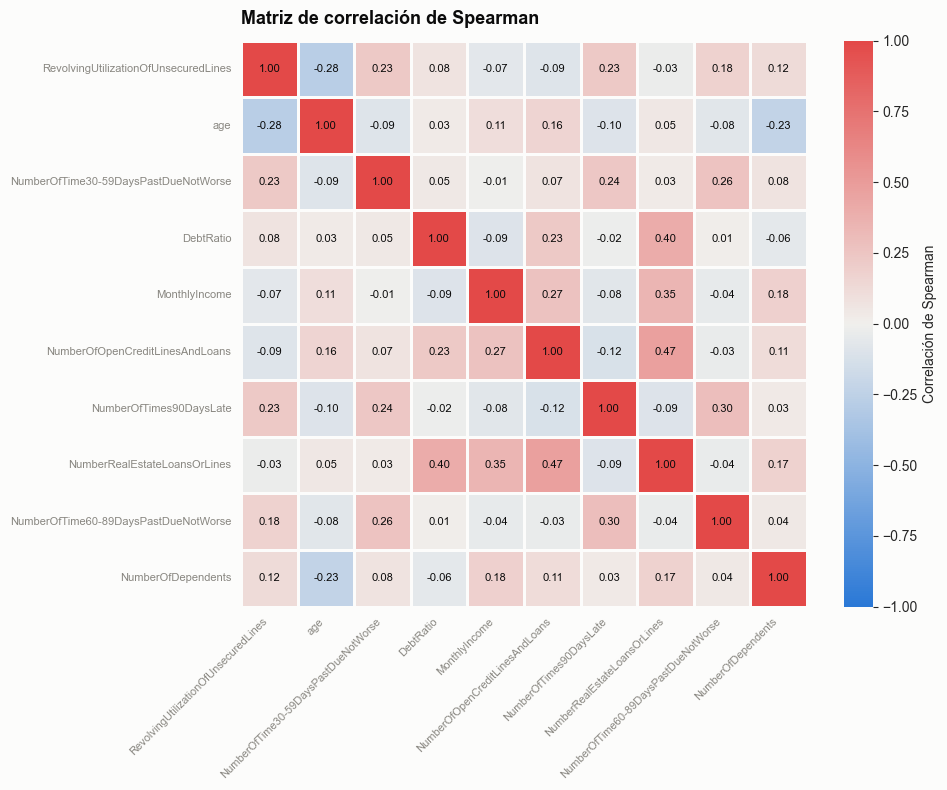

In [29]:
corr_spearman = df[num_cols].corr(method="spearman")

cmap_diverging = sns.blend_palette([DIVERGE_LOW, DIVERGE_MID, DIVERGE_HIGH], as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap=cmap_diverging, center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, linecolor="#fcfcfb",
            cbar_kws={"label": "Correlación de Spearman"}, ax=ax,
            annot_kws={"fontsize": 8, "color": PRIMARY_TEXT})
ax.set_title("Matriz de correlación de Spearman", fontsize=13, color=PRIMARY_TEXT,
             fontweight="bold", loc="left", pad=12)
ax.tick_params(colors=MUTED_TEXT, labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.2 Relaciones destacadas

In [30]:
pares = (
    corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))
    .stack()
    .rename("spearman")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares["abs_spearman"] = pares["spearman"].abs()
top_pares = pares.sort_values("abs_spearman", ascending=False).head(2)
top_pares

,variable_1,variable_2,spearman,abs_spearman
36,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,0.472824,0.472824
27,DebtRatio,NumberRealEstateLoansOrLines,0.400240,0.400240


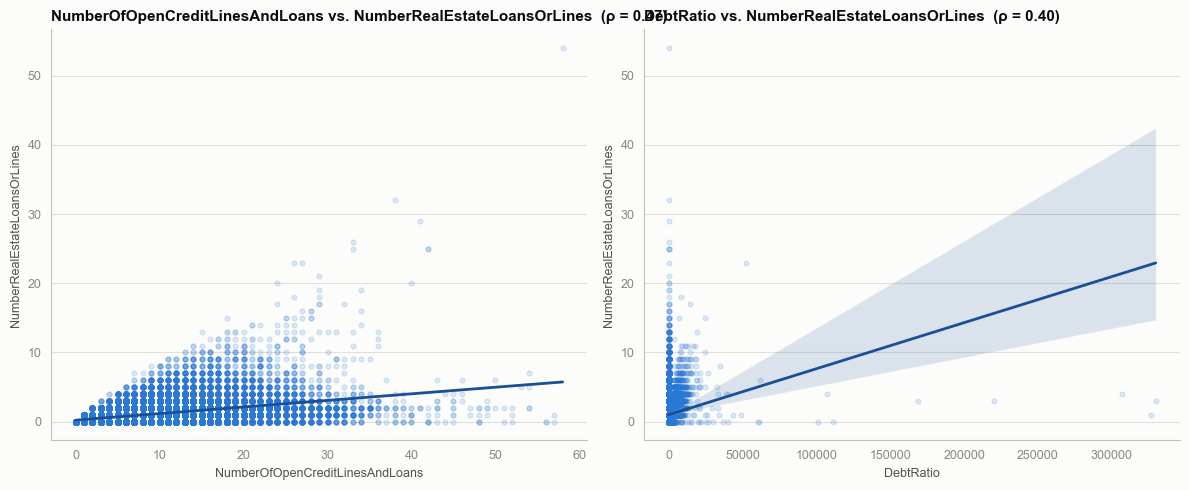

In [31]:
fig, axes = plt.subplots(1, len(top_pares), figsize=(6 * len(top_pares), 5))
if len(top_pares) == 1:
    axes = [axes]

for ax, fila in zip(axes, top_pares.itertuples()):
    sns.regplot(data=df, x=fila.variable_1, y=fila.variable_2, ax=ax,
                scatter_kws={"color": COLOR_SEQ, "alpha": 0.15, "s": 12},
                line_kws={"color": COLOR_SEQ_DARK, "linewidth": 2})
    style_ax(ax, title=f"{fila.variable_1} vs. {fila.variable_2}  (ρ = {fila.spearman:.2f})",
              xlabel=fila.variable_1, ylabel=fila.variable_2)

plt.tight_layout()
plt.show()

In [32]:
for fila in top_pares.itertuples():
    fuerza = "fuerte" if fila.abs_spearman >= 0.6 else ("moderada" if fila.abs_spearman >= 0.3 else "débil")
    direccion = "positiva" if fila.spearman > 0 else "negativa"
    print(
        f"'{fila.variable_1}' y '{fila.variable_2}': correlación {direccion} {fuerza} "
        f"(ρ = {fila.spearman:.2f}). "
        + ("Sugiere posible redundancia entre ambas variables para el modelamiento."
           if fila.abs_spearman >= 0.6 else
           "No sugiere redundancia relevante entre ambas variables.")
    )

'NumberOfOpenCreditLinesAndLoans' y 'NumberRealEstateLoansOrLines': correlación positiva moderada (ρ = 0.47). No sugiere redundancia relevante entre ambas variables.
'DebtRatio' y 'NumberRealEstateLoansOrLines': correlación positiva moderada (ρ = 0.40). No sugiere redundancia relevante entre ambas variables.


## 7. Conclusión general

Este EDA recorrió el dataset **GiveMeSomeCredit** por el camino de siempre: estructura de los datos, univariado, bivariado, comparación formal de grupos (diagnóstico descriptivo de forma → Mann-Whitney U con tamaño de efecto r de Rosenthal y AUC univariado) y correlación entre variables (Spearman).

**Lo que queda claro:**

- La variable objetivo tiene un desbalance marcado: 93.32% sin morosidad grave contra 6.68% con morosidad grave. Eso hay que tenerlo presente al entrenar cualquier clasificador.
- Con N ≈ 150,000, las pruebas formales de normalidad (Kolmogorov-Smirnov, Shapiro-Wilk, Lilliefors) no se usan como criterio: sufren de exceso de potencia y rechazarían normalidad en cualquier variable real, sin relevancia práctica. La justificación de usar métodos no paramétricos se apoya en su lugar en asimetría, curtosis, naturaleza discreta y colas pesadas — presentes, en mayor o menor medida, en las diez variables numéricas.
- `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `MonthlyIncome` y las tres variables de conteo de atrasos vienen con asimetría fuerte y atípicos severos. Las de conteo de atrasos, además, tenían el código de valor especial 96/98 (0.18% de las filas), tratado formalmente como `NaN` en la sección 3.4 antes de cualquier estadístico o prueba, con una bandera (`flag_codigo_especial_mora`) reservada para la fase de modelado.
- `age` tenía un registro con valor 0, un error de captura sin ambigüedad, eliminado en la sección 2 (1 fila de 150,000).
- `DebtRatio` supera 1 en el 23% de los registros, un fenómeno que deja de ser misterioso al cruzarlo con el ingreso: en el 19.8% de los casos donde `MonthlyIncome` no fue reportado originalmente, `DebtRatio` no es una razón sino, muy probablemente, una cifra de deuda absoluta — la mediana en ese subgrupo es ≈1,159, contra ≈0.30 en el subgrupo con ingreso reportado. Se documenta el fenómeno y se deja la bandera `ingreso_no_reportado` para segmentar o transformar en la fase de modelado.
- Mann-Whitney U (sección 5), interpretado como prueba de dominancia estocástica (no solo de medianas, dado que las formas de las distribuciones difieren entre grupos), encuentra diferencias estadísticamente significativas en las ocho variables analizadas — esperable a este tamaño de muestra. Ordenando por tamaño de efecto, `NumberOfTimes90DaysLate`, las otras dos variables de mora, `RevolvingUtilizationOfUnsecuredLines` y `age` muestran separación práctica real entre clientes con y sin morosidad grave; `DebtRatio`, `MonthlyIncome` y `NumberOfOpenCreditLinesAndLoans` son significativas pero con tamaño de efecto trivial — un buen recordatorio de que, a N grande, el p-valor por sí solo no basta para decidir qué variables importan.
- La matriz de Spearman (sección 6.1) no muestra correlaciones fuertes entre predictoras (máximo ≈0.47), útil para anticipar redundancia antes de armar un modelo.

De aquí para adelante: definir el tratamiento final del código especial 96/98 y de la anomalía de `DebtRatio` (dummies, imputación o segmentación, según lo documentado en 3.4), y seleccionar variables para modelar el riesgo de morosidad grave.

## 8. Modelado predictivo: Regresión Logística con regularización (Ridge y Lasso)

Esta sección construye modelos de clasificación para predecir `SeriousDlqin2yrs` a partir de las variables exploradas en las secciones anteriores. Se comparan tres variantes de regresión logística:

- **Logística base**: sin búsqueda del hiperparámetro de regularización (`C = 1`, valor por defecto de scikit-learn).
- **Ridge (L2)**: penalización proporcional a la suma de cuadrados de los coeficientes; el hiperparámetro `C` se selecciona por validación cruzada.
- **Lasso (L1)**: penalización proporcional a la suma de valores absolutos de los coeficientes, capaz de llevar coeficientes exactamente a cero (selección de variables); `C` también se selecciona por validación cruzada.

Como se señaló en la sección 3.5, la variable objetivo está fuertemente desbalanceada (93.32% / 6.68%), por lo que el *accuracy* debe interpretarse con cautela: un modelo que prediga siempre la clase mayoritaria ya alcanzaría un nivel de exactitud similar. Por eso, además del score y el error solicitados, se reportan métricas pensadas para clases desbalanceadas:

- **Score (accuracy)**: proporción de predicciones correctas sobre el conjunto de prueba.
- **Error (log-loss)**: pérdida logarítmica sobre las probabilidades predichas; penaliza la mala calibración y es más sensible que el accuracy en un contexto desbalanceado.
- **Precision, recall y F1 por clase**: para no perder de vista qué tan bien identifica el modelo a los clientes en riesgo (clase 1), el punto ciego del accuracy.
- **AUC-ROC**: resume la capacidad del modelo de separar ambas clases con independencia del umbral de decisión.

### 8.1 Preparación de los datos

**Código especial 96/98 (retomando la sección 3.4):** allí los valores 96/98 de las tres variables de mora se reemplazaron temporalmente por `NaN`, solo para que las medianas, las pruebas de Mann-Whitney y la correlación de las secciones 4 a 6 no quedaran contaminadas — la fila no se eliminó, el tratamiento definitivo se dejó pendiente para el modelado. Aquí se aplica la estrategia recomendada en esa misma sección: imputar esos `NaN` con la mediana (0 en los tres casos, porque la enorme mayoría de valores legítimos son 0) y conservar `flag_codigo_especial_mora` como variable binaria de entrada, para que el modelo no pierda la señal de que esas filas tenían un código especial en vez de un conteo real de atrasos.

In [33]:
df_modelo = df.copy()
df_modelo["SeriousDlqin2yrs"] = df_modelo["SeriousDlqin2yrs"].astype(int)  # de categórica (sección 2.2) a numérica para sklearn

medianas_mora = df_modelo[mora_cols].median()
for col in mora_cols:
    df_modelo[col] = df_modelo[col].fillna(medianas_mora[col])

print("Medianas usadas para imputar el código especial 96/98:")
print(medianas_mora)
df_modelo[mora_cols].isnull().sum().rename("n_nulos_restantes")

Medianas usadas para imputar el código especial 96/98:
NumberOfTime30-59DaysPastDueNotWorse    0.0
NumberOfTime60-89DaysPastDueNotWorse    0.0
NumberOfTimes90DaysLate                 0.0
dtype: float64


NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
Name: n_nulos_restantes, dtype: int64

**Transformación de `DebtRatio` (retomando la anomalía documentada más arriba):** esa sección advirtió que `DebtRatio` mezcla dos poblaciones — razón deuda/ingreso real y, cuando `ingreso_no_reportado` es verdadero, una cifra de deuda absoluta disfrazada de razón — y que por eso `StandardScaler` sin transformación previa no es apropiado, porque su varianza queda dominada por esos valores extremos. Se aplica aquí la transformación `log1p` sugerida en esa misma sección, que comprime el rango de la variable sin necesidad de separar manualmente las dos poblaciones. `ingreso_no_reportado` se conserva además como variable de entrada, para que el modelo disponga de la señal de segmentación aunque `DebtRatio` no se separe por grupo.

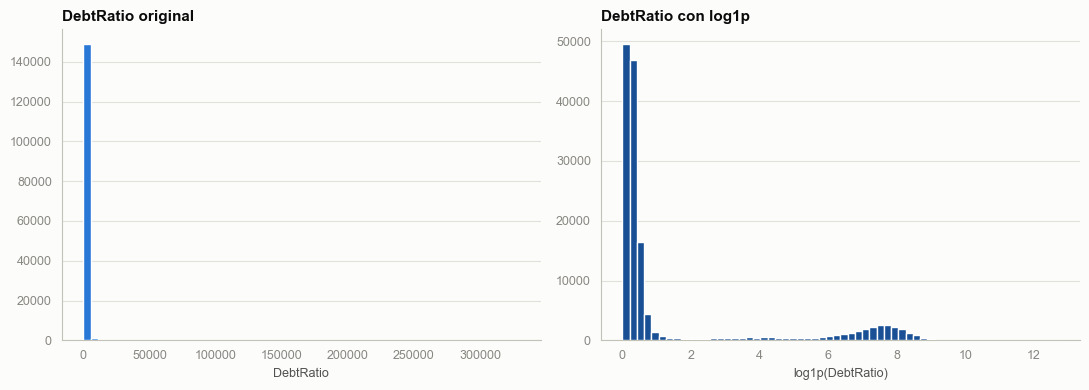

In [34]:
df_modelo["DebtRatio_log"] = np.log1p(df_modelo["DebtRatio"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_modelo["DebtRatio"], bins=60, color=COLOR_SEQ, zorder=3)
style_ax(axes[0], title="DebtRatio original", xlabel="DebtRatio")
axes[1].hist(df_modelo["DebtRatio_log"], bins=60, color=COLOR_SEQ_DARK, zorder=3)
style_ax(axes[1], title="DebtRatio con log1p", xlabel="log1p(DebtRatio)")
plt.tight_layout()
plt.show()

### 8.2 Selección de variables, división train/test y escalado

El conjunto de variables predictoras incluye las diez variables numéricas originales (con `DebtRatio` reemplazada por `DebtRatio_log`) más las dos banderas creadas durante el EDA (`flag_codigo_especial_mora`, `ingreso_no_reportado`), que documentan un tratamiento de datos en vez de descartarse. La división es 80/20 estratificada por la variable objetivo, y el escalado con `StandardScaler` es imprescindible para que la penalización L1/L2 trate a todas las variables en la misma escala — sin esto, variables de rango grande (`MonthlyIncome`) dominarían la penalización frente a variables de rango pequeño (`age`).

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
)

target = "SeriousDlqin2yrs"
features = [c for c in num_cols if c != "DebtRatio"] + [
    "DebtRatio_log", "flag_codigo_especial_mora", "ingreso_no_reportado",
]

X = df_modelo[features].astype(float)
y = df_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]:,} filas | Prueba: {X_test.shape[0]:,} filas")
print(f"Variables ({len(features)}): {features}")
print(f"Proporción de la clase 1 — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

Entrenamiento: 119,999 filas | Prueba: 30,000 filas
Variables (12): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'DebtRatio_log', 'flag_codigo_especial_mora', 'ingreso_no_reportado']
Proporción de la clase 1 — train: 0.0668 | test: 0.0668


### 8.3 Ajuste de los modelos

El hiperparámetro `C` (inverso de la fuerza de regularización) de Ridge y Lasso se selecciona con `LogisticRegressionCV`, usando `scoring="neg_log_loss"` para optimizar directamente la métrica de error, con validación cruzada de 5 particiones estratificadas sobre el conjunto de entrenamiento — el conjunto de prueba no participa en la selección de `C`, solo en la evaluación final.

In [36]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

modelos = {}

# Logística base (sin búsqueda de C): referencia sin regularización ajustada
log_base = LogisticRegression(max_iter=2000, random_state=42)
log_base.fit(X_train_esc, y_train)
modelos["Logística base"] = (log_base, log_base.C)

# Ridge (L2): penaliza la suma de cuadrados de los coeficientes
ridge_cv = LogisticRegressionCV(
    Cs=10, cv=5, penalty="l2", solver="lbfgs",
    scoring="neg_log_loss", max_iter=2000, random_state=42, n_jobs=-1
)
ridge_cv.fit(X_train_esc, y_train)
modelos["Ridge (L2)"] = (ridge_cv, ridge_cv.C_[0])

# Lasso (L1): penaliza la suma de valores absolutos, puede anular coeficientes
lasso_cv = LogisticRegressionCV(
    Cs=10, cv=5, penalty="l1", solver="liblinear",
    scoring="neg_log_loss", max_iter=2000, random_state=42, n_jobs=-1
)
lasso_cv.fit(X_train_esc, y_train)
modelos["Lasso (L1)"] = (lasso_cv, lasso_cv.C_[0])

for nombre, (_, c_opt) in modelos.items():
    print(f"{nombre}: C óptimo = {c_opt:.4f}")

Logística base: C óptimo = 1.0000
Ridge (L2): C óptimo = 0.0464
Lasso (L1): C óptimo = 0.3594


### 8.4 Evaluación: score, error y AUC-ROC

In [37]:
filas_modelos = []
for nombre, (modelo, c_opt) in modelos.items():
    y_pred = modelo.predict(X_test_esc)
    y_proba = modelo.predict_proba(X_test_esc)
    filas_modelos.append({
        "modelo": nombre,
        "C_optimo": round(c_opt, 4),
        "accuracy (score)": round(accuracy_score(y_test, y_pred), 4),
        "log_loss (error)": round(log_loss(y_test, y_proba), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba[:, 1]), 4),
    })

resultados_modelos = pd.DataFrame(filas_modelos)
baseline_ingenuo = round((y_test == 0).mean(), 4)
print(f"Referencia — predecir siempre la clase mayoritaria: accuracy = {baseline_ingenuo}")
resultados_modelos

Referencia — predecir siempre la clase mayoritaria: accuracy = 0.9332


,modelo,C_optimo,accuracy (score),log_loss (error),roc_auc
0,Logística base,1.0000,0.936,0.1984,0.8212
1,Ridge (L2),0.0464,0.936,0.1985,0.8212
2,Lasso (L1),0.3594,0.936,0.1984,0.8213


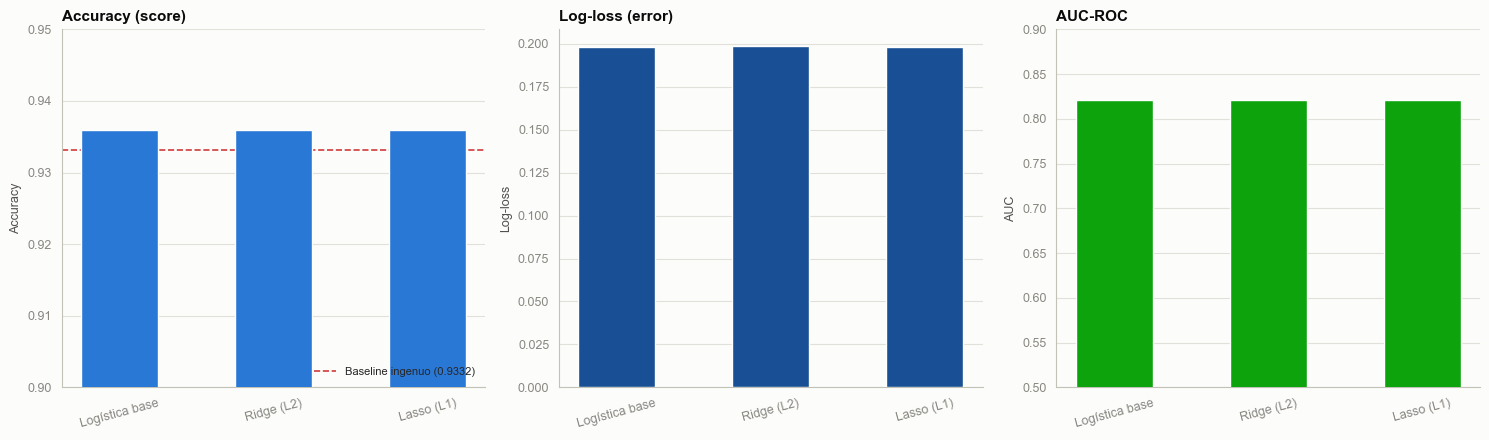

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(resultados_modelos["modelo"], resultados_modelos["accuracy (score)"],
            color=COLOR_SEQ, width=0.5, zorder=3)
axes[0].axhline(baseline_ingenuo, color=COLOR_CRITICAL, linestyle="--", linewidth=1.2,
                label=f"Baseline ingenuo ({baseline_ingenuo})")
axes[0].set_ylim(0.9, 0.95)
style_ax(axes[0], title="Accuracy (score)", ylabel="Accuracy")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(resultados_modelos["modelo"], resultados_modelos["log_loss (error)"],
            color=COLOR_SEQ_DARK, width=0.5, zorder=3)
style_ax(axes[1], title="Log-loss (error)", ylabel="Log-loss")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(resultados_modelos["modelo"], resultados_modelos["roc_auc"],
            color=COLOR_GOOD, width=0.5, zorder=3)
axes[2].set_ylim(0.5, 0.9)
style_ax(axes[2], title="AUC-ROC", ylabel="AUC")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Los tres modelos logísticos obtienen un desempeño prácticamente idéntico: **accuracy ≈ 93.6%**, **log-loss ≈ 0.198** y **AUC-ROC ≈ 0.821**, con `C` óptimo de 0.0464 (Ridge) y 0.3594 (Lasso) — la regularización apenas mueve el resultado frente a la logística base, lo esperable con ~150,000 observaciones y solo 12 variables, donde el riesgo de sobreajuste es bajo y la penalización tiene poco margen para mejorar la generalización.

El *accuracy* (93.6%) es apenas superior al baseline ingenuo de predecir siempre "sin morosidad" (93.32%), lo cual confirma la advertencia de la sección 3.5: con clases tan desbalanceadas, el accuracy por sí solo dice poco sobre la capacidad real del modelo. El **AUC-ROC (0.821)** es la métrica que revela lo que el accuracy oculta: bien por encima de 0.5 (un clasificador aleatorio), muestra que el modelo sí separa razonablemente bien ambas clases en términos de las probabilidades que asigna, con independencia del umbral de decisión que se use para convertir esa probabilidad en una predicción binaria.

### 8.5 Coeficientes: efecto de la regularización

In [39]:
coef_comparacion = pd.DataFrame({
    "variable": features,
    "Logística base": log_base.coef_[0],
    "Ridge (L2)": ridge_cv.coef_[0],
    "Lasso (L1)": lasso_cv.coef_[0],
}).set_index("variable").round(4)

coef_comparacion["Lasso == 0"] = coef_comparacion["Lasso (L1)"] == 0
coef_comparacion.sort_values("Logística base", key=abs, ascending=False)

,Logística base,Ridge (L2),Lasso (L1),Lasso == 0
variable,,,,
NumberOfTimes90DaysLate,0.4225,0.4220,0.4224,False
NumberOfTime30-59DaysPastDueNotWorse,0.3903,0.3899,0.3903,False
age,-0.3864,-0.3877,-0.3875,False
MonthlyIncome,-0.3245,-0.3086,-0.3134,False
NumberOfTime60-89DaysPastDueNotWorse,0.2562,0.2567,0.2563,False
flag_codigo_especial_mora,0.1238,0.1237,0.1234,False
DebtRatio_log,-0.1086,-0.1129,-0.1171,False
NumberRealEstateLoansOrLines,0.1082,0.1065,0.1068,False
NumberOfDependents,0.0673,0.0667,0.0667,False


Con `C` óptimo ≈ 0.36 en Lasso (una regularización moderada, no extrema), ninguna de las 12 variables es llevada a cero: todas aportan señal suficiente como para que ni siquiera la penalización L1 las descarte por completo. La mayoría de los signos es consistente con la intuición de negocio y con los hallazgos de las secciones 4 y 5: las tres variables de atrasos históricos, `flag_codigo_especial_mora` y `NumberRealEstateLoansOrLines` tienen coeficiente positivo (más atrasos, código especial de mora o líneas hipotecarias → mayor riesgo), mientras que `age` y `MonthlyIncome` tienen coeficiente negativo (clientes de mayor edad e ingreso son menos riesgosos).

Dos variables se salen de esa lectura simple y quedan como candidatas para una siguiente iteración:

- **`DebtRatio_log`** tiene coeficiente negativo (-0.11), en el sentido contrario al esperado (más deuda relativa al ingreso debería asociarse a más riesgo, no a menos). Es plausible que, incluso después de aplicar `log1p` y de controlar por `ingreso_no_reportado`, la mezcla de poblaciones documentada en la anomalía de `DebtRatio` (razón real vs. cifra de deuda absoluta) siga distorsionando parcialmente su relación lineal con el riesgo — el tratamiento aplicado aquí atenúa el problema de escala para `StandardScaler`, pero no separa por completo ambas poblaciones.
- **`RevolvingUtilizationOfUnsecuredLines`** tiene un coeficiente prácticamente nulo (0.0026) a pesar de mostrar uno de los tamaños de efecto más grandes en la comparación de grupos de la sección 5. La explicación más probable es la misma que motivó transformar `DebtRatio`: esta variable también tiene atípicos severos (secciones 3.2–3.3) que dominan su varianza bajo `StandardScaler`, diluyendo su efecto lineal. Aplicarle una transformación similar (`log1p` o winsorización) es un candidato natural para la siguiente iteración del modelo.

### 8.6 Matriz de confusión, reporte de clasificación y curva ROC del mejor modelo

El *accuracy* y el AUC-ROC resumen el desempeño global, pero ocultan cómo se distribuyen los errores entre clases. La matriz de confusión y el `classification_report` (precision, recall y F1 por clase) permiten cuantificar, en concreto, qué tan bien identifica el modelo a los clientes en riesgo — la clase minoritaria y la que más importa para el negocio.

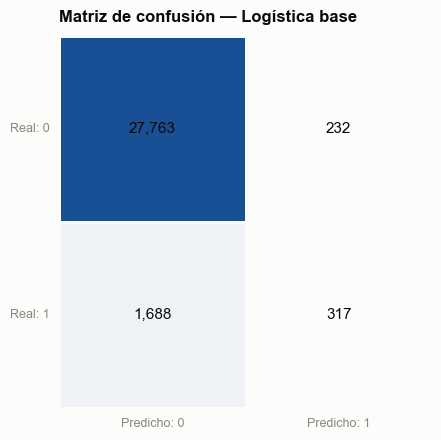

Reporte de clasificación — Logística base

                   precision    recall  f1-score   support

Sin morosidad (0)       0.94      0.99      0.97     27995
Con morosidad (1)       0.58      0.16      0.25      2005

         accuracy                           0.94     30000
        macro avg       0.76      0.57      0.61     30000
     weighted avg       0.92      0.94      0.92     30000



In [40]:
mejor_nombre = resultados_modelos.loc[resultados_modelos["log_loss (error)"].idxmin(), "modelo"]
mejor_modelo = modelos[mejor_nombre][0]
y_pred_mejor = mejor_modelo.predict(X_test_esc)
y_proba_mejor = mejor_modelo.predict_proba(X_test_esc)[:, 1]

matriz = confusion_matrix(y_test, y_pred_mejor)
cmap_confusion = sns.blend_palette(["#fcfcfb", COLOR_SEQ_DARK], as_cmap=True)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(matriz, annot=True, fmt=",d", cmap=cmap_confusion, cbar=False, square=True,
            linewidths=1, linecolor="#fcfcfb", annot_kws={"fontsize": 11, "color": PRIMARY_TEXT}, ax=ax)
ax.set_xticklabels(["Predicho: 0", "Predicho: 1"], color=MUTED_TEXT, fontsize=9)
ax.set_yticklabels(["Real: 0", "Real: 1"], color=MUTED_TEXT, fontsize=9, rotation=0)
ax.set_title(f"Matriz de confusión — {mejor_nombre}", fontsize=12, color=PRIMARY_TEXT,
             fontweight="bold", loc="left", pad=10)
plt.tight_layout()
plt.show()

print(f"Reporte de clasificación — {mejor_nombre}\n")
print(classification_report(y_test, y_pred_mejor,
                             target_names=["Sin morosidad (0)", "Con morosidad (1)"]))

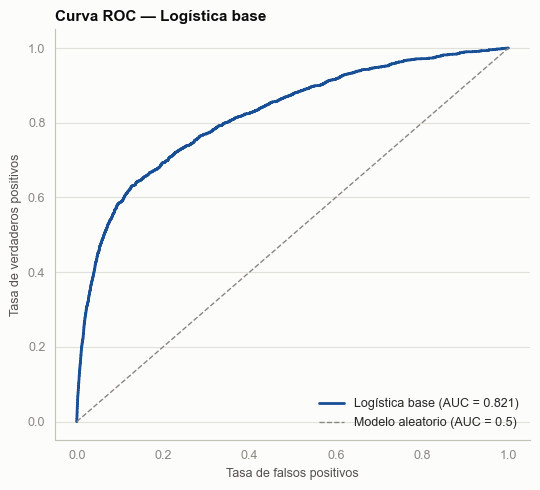

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_proba_mejor)
auc_mejor = roc_auc_score(y_test, y_proba_mejor)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=COLOR_SEQ_DARK, linewidth=2, label=f"{mejor_nombre} (AUC = {auc_mejor:.3f})")
ax.plot([0, 1], [0, 1], color=MUTED_TEXT, linestyle="--", linewidth=1, label="Modelo aleatorio (AUC = 0.5)")
style_ax(ax, title=f"Curva ROC — {mejor_nombre}", xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos")
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

La matriz de confusión y el reporte de clasificación de la logística base — el modelo con menor log-loss — cuantifican exactamente la limitación que el accuracy ocultaba: de los 2,005 clientes con morosidad grave en el conjunto de prueba, el modelo identifica correctamente solo **317 (recall = 16%)** y pasa por alto **1,688**; de los 27,995 clientes sin morosidad, identifica correctamente 27,763 (recall = 99%). Cuando el modelo sí predice riesgo, acierta el 58% de las veces (precisión de la clase 1), pero eso ocurre con muy poca frecuencia dado el recall bajo — el F1 de la clase 1 queda en 0.25, frente a 0.97 de la clase 0.

Esto es consistente con no aplicar ponderación de clases (`class_weight`) ni ajustar el umbral de decisión: por defecto, `predict()` usa un umbral de 0.5, que en un dataset con 93.3% de la clase mayoritaria favorece sistemáticamente esa clase. El **AUC-ROC de 0.821**, en cambio, evalúa el modelo a través de todos los umbrales posibles y muestra que las probabilidades predichas sí ordenan razonablemente bien a los clientes por riesgo — la brecha entre un AUC decente y un recall bajo no es falta de señal, es el efecto del umbral por defecto sobre un problema desbalanceado. Ese ajuste (ponderación de clases, remuestreo o un umbral distinto de 0.5) queda fuera del alcance de esta sección, pero es la siguiente mejora natural del proyecto.

### 8.7 Síntesis

- Los tres modelos logísticos (base, Ridge, Lasso) obtienen un desempeño casi idéntico: **accuracy ≈ 93.6%**, **log-loss ≈ 0.198** y **AUC-ROC ≈ 0.821**, con `C` óptimo de 0.0464 (Ridge) y 0.3594 (Lasso) — una regularización moderada que apenas cambia el resultado frente a la logística sin ajustar.
- El accuracy es apenas superior al baseline ingenuo (93.6% vs. 93.32%), reflejo directo del desbalance de clases documentado en la sección 3.5; el AUC-ROC (0.821) es la métrica más informativa de las evaluadas para este dataset, porque no depende de un umbral de decisión concreto.
- Ninguna variable fue descartada por Lasso: las 12 variables de entrada (10 numéricas más las banderas `flag_codigo_especial_mora` e `ingreso_no_reportado`) aportan señal. La mayoría de los signos es coherente con el análisis exploratorio, salvo `DebtRatio_log` y `RevolvingUtilizationOfUnsecuredLines`, cuyos coeficientes resultan más débiles o contraintuitivos de lo esperado — ambas comparten el mismo tipo de problema (atípicos severos bajo `StandardScaler`) y son el primer candidato de mejora.
- La matriz de confusión y el `classification_report` cuantifican lo que la sección de matriz de confusión anticipaba de forma cualitativa: el modelo captura solo el 16% de los clientes en riesgo real (recall de la clase 1), aunque el AUC-ROC (0.821) muestra que sí existe señal suficiente para ordenar el riesgo — la brecha es el umbral de decisión por defecto en un problema desbalanceado, no ausencia de información.
- Esta sección retoma explícitamente dos tratamientos que la sección 3.4 y la anomalía de `DebtRatio` habían dejado pendientes para el modelado: los códigos especiales 96/98 se imputan con la mediana conservando `flag_codigo_especial_mora` (en vez de eliminar filas), y `DebtRatio` se transforma con `log1p` antes de escalar (en vez de usar `StandardScaler` directamente sobre la variable sin tratar).
- Próximos pasos naturales: cerrar la brecha de recall en la clase minoritaria (`class_weight="balanced"`, remuestreo o ajuste de umbral usando la curva ROC) y aplicar a `RevolvingUtilizationOfUnsecuredLines` una transformación similar a la de `DebtRatio`.